# Disease velocity on decoded torus surfaces at ages 60, 70, and 80

This notebook evaluates age-specific disease velocity on the **surface decoded at that
age**. It compares seven relevant models:

1. conditioned cocycle shape loss, multiple pairs;
2. conditioned cocycle shape loss, single pair;
3. disentangled 64/128/64, best checkpoint (epoch 500);
4. disentangled 64/128/64, latest checkpoint (epoch 2000);
5. counterfactual disentangled, latest checkpoint.
6. additive strong, best checkpoint (epoch 1000);
7. additive strong, latest checkpoint.

The analysis is performed for:

- a synthetic mean-latent diseased trajectory;
- `ID_017`, whose observed scans are near age 60;
- `ID_028`, whose observed scans are near age 70;
- `ID_004`, whose observed scans are near age 80.

For each anchor, the model is transported to ages 60, 70, and 80. At each age:

1. the age-specific latent \(z_t\) is decoded into a surface;
2. disease velocity is calculated at that latent and time;
3. latent disease speed \(\|v_d\|\) is measured;
4. velocity is projected through the decoder into signed surface-normal speed.

## Important comparison semantics

For disentangled models, `disease velocity` is the explicit disease component. For
conditioned models, it is the diagnosis contrast

\[
V(z,t,t,d=1)-V(z,t,t,d=0).
\]

These are useful comparative effects, but they are not mathematically identical objects.
Subject ages outside the observed age range are marked as counterfactual extrapolations.


## Reliable viewing in VS Code Remote

Interactive 3D figures are saved outside the notebook under
`analysis_torus_age_specific_disease_velocity/figures/`. The generated
`figures/index.html` links every colored surface, arrow figure, metric plot, and
perturbation figure. This avoids VS Code dropping outputs when the notebook contains many
large Plotly payloads.

By default, heavy Plotly figures are **not embedded inline**. Set
`SHOW_INLINE_PLOTLY = True` in the configuration cell only when viewing a small subset.

In [1]:
import json
import math
import random
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import torch
import trimesh
from IPython.display import HTML, display
from plotly.subplots import make_subplots
from skimage.measure import marching_cubes

ROOT = Path("/home/jakaria/INR/Deep3DComp")
if not ROOT.exists():
    ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from deep_sdf import data as deep_sdf_data
from networks.deep_sdf_decoder import Decoder
from networks.longitudinal_disentangled_flow import (
    build_temporal_flow as build_counterfactual_disentangled_flow,
)
from networks.longitudinal_disentangled_flow_64_128_64_adv import (
    build_temporal_flow as build_subset64_flow,
)
from networks.longitudinal_additive_flow import (
    build_temporal_flow as build_additive_flow,
)

SEED = 23
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

GPU_ID = 0
if torch.cuda.is_available():
    torch.cuda.set_device(GPU_ID)
DEVICE = torch.device(f"cuda:{GPU_ID}" if torch.cuda.is_available() else "cpu")

AGES = (60.0, 70.0, 80.0)
DIAGNOSIS = 1.0
MEAN_REFERENCE_AGE = 60.0

GRID_RES = 64
GRID_BATCH = 2**17
SURFACE_BATCH = 4096
FD_EPS = 1e-3
LOCAL_STEP = 0.10

ANCHOR_STEPS = 250
ANCHOR_SAMPLES = 4096

# Arrow figures use shafts plus arrowheads, with origins offset outside the surface.
ARROW_COUNT = 140
ARROW_TOP_MAGNITUDE_COUNT = 30
ARROW_ORIGIN_OFFSET = 0.012
ARROW_MIN_LENGTH = 0.018
ARROW_MAX_ADDITIONAL_LENGTH = 0.105
ARROW_HEAD_LENGTH = 0.035

BUMP_NEAR_HALFWIDTH_DEG = 15.0
BUMP_OUTER_QUANTILE = 0.85

# Reliable remote rendering: save every figure externally instead of embedding dozens
# of large Plotly JSON payloads in the notebook.
OUTPUT_DIR = ROOT / "analysis_torus_age_specific_disease_velocity"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SAVE_INTERACTIVE_HTML = True
SAVE_PLOTLY_PNG = False  # Global default; selected figures request PNG explicitly.
SHOW_INLINE_PLOTLY = False
SHOW_INLINE_MATPLOTLIB = True
INLINE_PLOTLY_ANCHORS = {"mean_shape"}
FIGURE_MANIFEST = {}


def figure_slug(value):
    text = re.sub(r"[^A-Za-z0-9._-]+", "_", str(value)).strip("_")
    return text or "figure"


def register_figure(path, title, category):
    path = Path(path)
    FIGURE_MANIFEST[str(path)] = {
        "path": path,
        "title": str(title),
        "category": str(category),
    }
    print("Saved figure:", path)


def save_plotly_figure(
    fig, filename, title, category, show_inline=False, save_png=None
):
    html_path = FIGURE_DIR / f"{figure_slug(filename)}.html"
    if SAVE_INTERACTIVE_HTML:
        # "directory" writes one shared plotly.min.js bundle, then references it from
        # every HTML file. This is much smaller than embedding Plotly in every figure.
        fig.write_html(
            html_path,
            include_plotlyjs="directory",
            full_html=True,
            auto_open=False,
        )
        register_figure(html_path, title, category)
    export_png = SAVE_PLOTLY_PNG if save_png is None else bool(save_png)
    if export_png:
        png_path = FIGURE_DIR / f"{figure_slug(filename)}.png"
        fig.write_image(png_path, scale=1.5)
        register_figure(png_path, title + " (PNG)", category)
    if SHOW_INLINE_PLOTLY and show_inline:
        fig.show()
    return html_path


def save_matplotlib_figure(fig, filename, title, category):
    png_path = FIGURE_DIR / f"{figure_slug(filename)}.png"
    fig.savefig(png_path, dpi=170, bbox_inches="tight", facecolor="white")
    register_figure(png_path, title, category)
    if SHOW_INLINE_MATPLOTLIB:
        plt.show()
    else:
        plt.close(fig)
    return png_path


def write_figure_index():
    entries = sorted(
        FIGURE_MANIFEST.values(),
        key=lambda item: (item["category"], item["title"], str(item["path"])),
    )
    groups = {}
    for item in entries:
        groups.setdefault(item["category"], []).append(item)

    chunks = [
        "<!doctype html><html><head><meta charset='utf-8'>",
        "<title>Torus age-specific disease velocity figures</title>",
        "<style>body{font-family:Arial,sans-serif;max-width:1100px;margin:32px auto;",
        "padding:0 20px;color:#202020}h1{margin-bottom:8px}h2{margin-top:30px}",
        "li{margin:9px 0}a{color:#0b5cad;text-decoration:none}a:hover{text-decoration:underline}",
        "code{background:#f1f1f1;padding:2px 5px;border-radius:3px}</style></head><body>",
        "<h1>Torus age-specific disease velocity figures</h1>",
        "<p>Open interactive HTML figures in a browser. PNG metric plots can be viewed ",
        "directly in VS Code. Files are regenerated when the notebook figure cells run.</p>",
    ]
    for category, items in groups.items():
        chunks.append(f"<h2>{category}</h2><ul>")
        for item in items:
            relative = item["path"].relative_to(FIGURE_DIR)
            chunks.append(
                f"<li><a href='{relative.as_posix()}'>{item['title']}</a></li>"
            )
        chunks.append("</ul>")
    chunks.append("</body></html>")
    index_path = FIGURE_DIR / "index.html"
    index_path.write_text("".join(chunks), encoding="utf-8")
    print("Figure index:", index_path)
    return index_path

BASE = ROOT / "examples" / "Torus_subset_100_id_age_progression"
MULTIPLE_PAIR_DIR = (
    BASE / "longitudinal_age_disease_conditioned_cocycle_shape_pair_loss_multiple_pairs"
)
SINGLE_PAIR_DIR = BASE / "longitudinal_age_disease_conditioned_cocycle_shape_pair_loss"
SUBSET64_DIR = (
    BASE
    / "longitudinal_age_disease_conditioned_cocycle_shape_pair_loss_multiple_pairs_disentangled_velocity_64_128_64_binary_margin_adv"
)
COUNTERFACTUAL_DIR = (
    BASE
    / "longitudinal_age_disease_conditioned_cocycle_shape_pair_loss_multiple_pairs_disentangled_velocity_counterfactual"
)
ADDITIVE_STRONG_DIR = (
    BASE
    / "longitudinal_age_disease_additive_velocity_disentanglement_strong_residual_invariance_adv"
)

print("Device:", DEVICE)
print("Ages:", AGES)
print("Grid resolution:", GRID_RES)
print("External figure directory:", FIGURE_DIR)
print("Inline Plotly enabled:", SHOW_INLINE_PLOTLY)


Device: cuda:0
Ages: (60.0, 70.0, 80.0)
Grid resolution: 64
External figure directory: /home/jakaria/INR/Deep3DComp/analysis_torus_age_specific_disease_velocity/figures
Inline Plotly enabled: False


## Load all model checkpoints


In [2]:
class TemporalFlowMLP(torch.nn.Module):
    def __init__(self, latent_size, hidden_dims, age_condition_dim=0):
        super().__init__()
        self.age_condition_dim = max(0, int(age_condition_dim))
        dims = [latent_size + 2 + self.age_condition_dim] + list(hidden_dims) + [latent_size]
        layers = []
        for index in range(len(dims) - 1):
            layers.append(torch.nn.Linear(dims[index], dims[index + 1]))
            if index < len(dims) - 2:
                layers.append(torch.nn.ReLU(inplace=True))
        self.net = torch.nn.Sequential(*layers)

    def _condition(self, z, value):
        if self.age_condition_dim <= 0:
            return None
        if value is None:
            return torch.zeros(
                z.shape[0], self.age_condition_dim, device=z.device, dtype=z.dtype
            )
        value = value.to(device=z.device, dtype=z.dtype)
        if value.ndim == 1:
            value = value.unsqueeze(1)
        if value.shape[1] == self.age_condition_dim:
            return value
        if value.shape[1] == 1 and self.age_condition_dim > 1:
            return value.repeat(1, self.age_condition_dim)
        raise ValueError(
            f"Condition width {value.shape[1]} != {self.age_condition_dim}"
        )

    def forward(self, z, s, t, age_cond=None):
        if s.ndim == 1:
            s = s.unsqueeze(1)
        if t.ndim == 1:
            t = t.unsqueeze(1)
        parts = [z, s, t]
        if self.age_condition_dim > 0:
            parts.append(self._condition(z, age_cond))
        return self.net(torch.cat(parts, dim=1))


def checkpoint_path(exp_dir, subdir, checkpoint):
    name = str(checkpoint)
    if not name.endswith(".pth"):
        name += ".pth"
    path = Path(exp_dir) / subdir / name
    if not path.exists():
        raise FileNotFoundError(path)
    return path


def strip_module_prefix(state):
    return {key.removeprefix("module."): value for key, value in state.items()}


def latent_weights(payload):
    latent = payload.get("latent_codes_state_dict", payload.get("latent_codes"))
    if isinstance(latent, dict):
        latent = latent["weight"]
    if latent.ndim == 3 and latent.shape[1] == 1:
        latent = latent[:, 0]
    return latent.detach().float()


MODEL_CONFIGS = {
    "multiple_pairs": {
        "label": "Conditioned - multiple pairs",
        "family": "conditioned",
        "exp_dir": MULTIPLE_PAIR_DIR,
        "checkpoint": "latest",
        "builder": None,
    },
    "single_pair": {
        "label": "Conditioned - single pair",
        "family": "conditioned",
        "exp_dir": SINGLE_PAIR_DIR,
        "checkpoint": "latest",
        "builder": None,
    },
    "subset64_best": {
        "label": "64/128/64 - best",
        "family": "disentangled",
        "exp_dir": SUBSET64_DIR,
        "checkpoint": "500",
        "builder": build_subset64_flow,
    },
    "subset64_latest": {
        "label": "64/128/64 - latest",
        "family": "disentangled",
        "exp_dir": SUBSET64_DIR,
        "checkpoint": "latest",
        "builder": build_subset64_flow,
    },
    "counterfactual_latest": {
        "label": "Counterfactual disentangled - latest",
        "family": "disentangled",
        "exp_dir": COUNTERFACTUAL_DIR,
        "checkpoint": "latest",
        "builder": build_counterfactual_disentangled_flow,
    },
    "additive_best": {
        "label": "Additive strong - best",
        "family": "additive",
        "exp_dir": ADDITIVE_STRONG_DIR,
        "checkpoint": "1000",
        "builder": build_additive_flow,
    },
    "additive_latest": {
        "label": "Additive strong - latest",
        "family": "additive",
        "exp_dir": ADDITIVE_STRONG_DIR,
        "checkpoint": "latest",
        "builder": build_additive_flow,
    },
}


def load_model(config):
    exp_dir = Path(config["exp_dir"])
    specs = json.loads((exp_dir / "specs.json").read_text())
    latent_size = int(specs["CodeLength"])
    decoder = Decoder(latent_size, **specs["NetworkSpecs"]).to(DEVICE)
    if config["builder"] is None:
        flow = TemporalFlowMLP(
            latent_size,
            list(specs.get("FlowHiddenDims", [256, 256])),
            age_condition_dim=int(specs.get("AgeConditionDim", 0)),
        ).to(DEVICE)
    else:
        flow = config["builder"](
            specs,
            latent_size,
            list(specs.get("FlowHiddenDims", [256, 256])),
            age_condition_dim=int(specs.get("AgeConditionDim", 0)),
        ).to(DEVICE)

    model_payload = torch.load(
        checkpoint_path(exp_dir, "ModelParameters", config["checkpoint"]),
        map_location=DEVICE,
    )
    decoder.load_state_dict(strip_module_prefix(model_payload["model_state_dict"]))
    flow.load_state_dict(strip_module_prefix(model_payload["flow_state_dict"]))
    decoder.eval()
    flow.eval()

    latent_payload = torch.load(
        checkpoint_path(exp_dir, "LatentCodes", config["checkpoint"]),
        map_location="cpu",
    )
    weights = latent_weights(latent_payload)
    return {
        **config,
        "specs": specs,
        "decoder": decoder,
        "flow": flow,
        "latent_weights": weights,
        "mean_z": weights.mean(dim=0, keepdim=True).to(DEVICE),
        "epoch": int(model_payload.get("epoch", -1)),
    }


MODELS = {key: load_model(config) for key, config in MODEL_CONFIGS.items()}
MODEL_TABLE = pd.DataFrame(
    [
        {
            "model_key": key,
            "model": model["label"],
            "family": model["family"],
            "checkpoint": model["checkpoint"],
            "epoch": model["epoch"],
            "mean_latent_norm": float(model["mean_z"].norm().item()),
        }
        for key, model in MODELS.items()
    ]
)
display(MODEL_TABLE)


,model_key,model,family,checkpoint,epoch,mean_latent_norm
0,multiple_pairs,Conditioned - multiple pairs,conditioned,latest,2000,0.020896
1,single_pair,Conditioned - single pair,conditioned,latest,2000,0.019476
2,subset64_best,64/128/64 - best,disentangled,500,500,0.027670
3,subset64_latest,64/128/64 - latest,disentangled,latest,2000,0.021397
4,counterfactual_latest,Counterfactual disentangled - latest,disentangled,latest,2000,0.020060
5,additive_best,Additive strong - best,additive,1000,1000,0.077780
6,additive_latest,Additive strong - latest,additive,latest,2000,0.052618


## Metadata, age conversion, and selected subjects

The selected diseased test subjects provide observed support near each requested age:

- `ID_017`: observed approximately 59.9–64.1 years;
- `ID_028`: observed approximately 68.0–72.9 years;
- `ID_004`: observed approximately 78.8–84.7 years.

For every subject, the anchor is fitted to the scan nearest its cohort target age. All
three ages are still evaluated. The table marks whether each requested age lies within the
subject's observed age range.


In [3]:
TORUS_RE = re.compile(r"^(?:ID|id)_(\d+)_t(\d+)$")


def parse_scan(scan):
    match = TORUS_RE.match(Path(str(scan)).stem)
    if match is None:
        raise ValueError(scan)
    return int(match.group(1)), int(match.group(2))


LABEL_OBJECT = torch.load(
    next(iter(MODELS.values()))["specs"]["AgeMetadataFile"], map_location="cpu"
)
LABEL_ROWS = []
for scan_id, payload in LABEL_OBJECT.items():
    row = {"scan_id": str(scan_id)}
    row.update(payload)
    LABEL_ROWS.append(row)
LABEL_DF = pd.DataFrame(LABEL_ROWS)

age_fit = LABEL_DF[["age", "age_norm"]].dropna()
AGE_TO_TIME_SLOPE, AGE_TO_TIME_INTERCEPT = np.polyfit(
    age_fit["age"].to_numpy(), age_fit["age_norm"].to_numpy(), 1
)


def age_to_time(age):
    return float(AGE_TO_TIME_SLOPE * float(age) + AGE_TO_TIME_INTERCEPT)


def build_test_records(specs):
    split_path = Path(specs["TestSplit"])
    if not split_path.exists():
        split_path = (
            ROOT
            / "examples"
            / "splits"
            / "splits_torus_progression_age"
            / "test_split_torus.json"
        )
    split = json.loads(split_path.read_text())
    records = []
    for item in split:
        scan_id = Path(str(item)).stem
        sid, tp = parse_scan(scan_id)
        label = LABEL_OBJECT[scan_id]
        records.append(
            {
                "scan_id": scan_id,
                "sid": sid,
                "tp": tp,
                "age": float(label["age"]),
                "time": float(label["age_norm"]),
                "diagnosis": int(label["diagnosis"]),
                "angle_deg": float(label.get("angle_deg", np.nan)),
                "bump_height": float(label.get("bump_height", np.nan)),
                "sdf_path": Path(specs["DataSource"]) / f"{scan_id}.npz",
            }
        )
    by_subject = {}
    for record in records:
        by_subject.setdefault(record["sid"], []).append(record)
    return {
        sid: sorted(items, key=lambda item: item["age"])
        for sid, items in by_subject.items()
    }


RECORDS = build_test_records(next(iter(MODELS.values()))["specs"])
SUBJECT_SPECS = {
    "ID_017_near_60": {"sid": 17, "cohort_age": 60.0},
    "ID_028_near_70": {"sid": 28, "cohort_age": 70.0},
    "ID_004_near_80": {"sid": 4, "cohort_age": 80.0},
}

selection_rows = []
for anchor_key, spec in SUBJECT_SPECS.items():
    subject_records = RECORDS[spec["sid"]]
    anchor_record = min(
        subject_records, key=lambda item: abs(item["age"] - spec["cohort_age"])
    )
    spec["anchor_record"] = anchor_record
    spec["observed_min_age"] = min(item["age"] for item in subject_records)
    spec["observed_max_age"] = max(item["age"] for item in subject_records)
    spec["bump_angle_deg"] = float(anchor_record["angle_deg"])
    for age in AGES:
        selection_rows.append(
            {
                "anchor_key": anchor_key,
                "sid": spec["sid"],
                "diagnosis": anchor_record["diagnosis"],
                "anchor_scan": anchor_record["scan_id"],
                "anchor_age": anchor_record["age"],
                "requested_age": age,
                "inside_observed_range": (
                    spec["observed_min_age"] <= age <= spec["observed_max_age"]
                ),
                "observed_range": (
                    f"{spec['observed_min_age']:.2f}–{spec['observed_max_age']:.2f}"
                ),
                "bump_angle_deg": spec["bump_angle_deg"],
            }
        )

SELECTION_TABLE = pd.DataFrame(selection_rows)
display(SELECTION_TABLE)
print(
    f"age_norm = {AGE_TO_TIME_SLOPE:.6f} * age "
    f"+ {AGE_TO_TIME_INTERCEPT:.6f}"
)


,anchor_key,sid,diagnosis,anchor_scan,anchor_age,requested_age,inside_observed_range,observed_range,bump_angle_deg
0,ID_017_near_60,17,1,ID_017_t0,59.929985,60.0,True,59.93–64.11,0.189017
1,ID_017_near_60,17,1,ID_017_t0,59.929985,70.0,False,59.93–64.11,0.189017
2,ID_017_near_60,17,1,ID_017_t0,59.929985,80.0,False,59.93–64.11,0.189017
3,ID_028_near_70,28,1,ID_028_t1,69.986992,60.0,False,68.04–72.93,-2.342173
4,ID_028_near_70,28,1,ID_028_t1,69.986992,70.0,True,68.04–72.93,-2.342173
5,ID_028_near_70,28,1,ID_028_t1,69.986992,80.0,False,68.04–72.93,-2.342173
6,ID_004_near_80,4,1,ID_004_t1,80.586525,60.0,False,78.75–84.68,-1.186624
7,ID_004_near_80,4,1,ID_004_t1,80.586525,70.0,False,78.75–84.68,-1.186624
8,ID_004_near_80,4,1,ID_004_t1,80.586525,80.0,True,78.75–84.68,-1.186624


age_norm = 0.025000 * age + -1.250000


## Decoder geometry and velocity projection


In [4]:
def decode_points(decoder, z, xyz, batch_size=GRID_BATCH):
    outputs = []
    with torch.no_grad():
        for start in range(0, xyz.shape[0], batch_size):
            points = xyz[start : start + batch_size].to(DEVICE)
            latent = z.reshape(1, -1).expand(points.shape[0], -1)
            outputs.append(
                decoder(torch.cat([latent, points], dim=1)).squeeze(-1).cpu()
            )
    return torch.cat(outputs).numpy()


def decode_grid(decoder, z, resolution=GRID_RES):
    axis = torch.linspace(-1.0, 1.0, int(resolution), dtype=torch.float32)
    xyz = torch.stack(
        torch.meshgrid(axis, axis, axis, indexing="ij"), dim=-1
    ).reshape(-1, 3)
    values = decode_points(decoder, z, xyz).reshape(
        resolution, resolution, resolution
    )
    return axis.numpy(), values


def mesh_from_grid(sdf_grid):
    spacing = 2.0 / (sdf_grid.shape[0] - 1)
    vertices, faces, _, _ = marching_cubes(
        sdf_grid, level=0.0, spacing=(spacing, spacing, spacing)
    )
    mesh = trimesh.Trimesh(
        vertices=vertices - 1.0, faces=faces, process=False
    )
    if mesh.is_watertight and mesh.volume < 0.0:
        mesh.invert()
    return mesh


def surface_geometry(decoder, z, resolution=GRID_RES):
    _, sdf_grid = decode_grid(decoder, z, resolution)
    mesh = mesh_from_grid(sdf_grid)
    vertices = torch.as_tensor(mesh.vertices, dtype=z.dtype, device=DEVICE)
    grad_parts = []
    for start in range(0, vertices.shape[0], SURFACE_BATCH):
        x = vertices[start : start + SURFACE_BATCH].detach().clone().requires_grad_(True)
        latent = z.detach().expand(x.shape[0], -1)
        sdf = decoder(torch.cat([latent, x], dim=1)).squeeze(-1)
        grad_parts.append(
            torch.autograd.grad(sdf.sum(), x, create_graph=False)[0].detach().cpu()
        )
    grad_x = torch.cat(grad_parts).numpy()
    grad_norm = np.linalg.norm(grad_x, axis=1) + 1e-12
    grad_unit = grad_x / grad_norm[:, None]
    mesh_normals = np.asarray(mesh.vertex_normals)
    alignment = np.einsum("ij,ij->i", grad_unit, mesh_normals)
    sign = 1.0 if np.nanmedian(alignment) >= 0.0 else -1.0
    return {
        "mesh": mesh,
        "vertices": vertices,
        "grad_norm": grad_norm,
        "outward_normals": sign * grad_unit,
        "sdf_to_outward_sign": sign,
        "normal_alignment": float(np.nanmedian(np.abs(alignment))),
    }


def latent_jvp(decoder, z, velocity, vertices):
    parts = []
    for start in range(0, vertices.shape[0], SURFACE_BATCH):
        x = vertices[start : start + SURFACE_BATCH].detach()
        z0 = z.detach().clone().requires_grad_(True)

        def decode_latent(latent):
            return decoder(
                torch.cat([latent.expand(x.shape[0], -1), x], dim=1)
            ).squeeze(-1)

        _, jvp = torch.autograd.functional.jvp(
            decode_latent,
            z0,
            velocity.detach(),
            create_graph=False,
            strict=False,
        )
        parts.append(jvp.detach().cpu())
    return torch.cat(parts).numpy()


def vertex_area_weights(mesh):
    weights = np.zeros(len(mesh.vertices), dtype=np.float64)
    contribution = np.asarray(mesh.area_faces, dtype=np.float64) / 3.0
    for corner in range(3):
        np.add.at(weights, np.asarray(mesh.faces)[:, corner], contribution)
    return weights


def surface_velocity(model, geometry, z, velocity):
    jvp = latent_jvp(
        model["decoder"], z, velocity, geometry["vertices"]
    )
    normal_speed = (
        -geometry["sdf_to_outward_sign"] * jvp / geometry["grad_norm"]
    )
    weights = vertex_area_weights(geometry["mesh"])
    return {
        "normal_speed": normal_speed,
        "arrows": normal_speed[:, None] * geometry["outward_normals"],
        "weights": weights,
        "latent_speed": float(velocity.norm().item()),
        "surface_rms_speed": float(
            np.sqrt(np.average(normal_speed**2, weights=weights))
        ),
        "surface_mean_abs_speed": float(
            np.average(np.abs(normal_speed), weights=weights)
        ),
        "net_volume_rate": float(np.sum(normal_speed * weights)),
        "outward_area_fraction": float(
            weights[normal_speed > 0].sum() / weights.sum()
        ),
    }


def bump_region_metrics(geometry, normal_speed, bump_angle_deg):
    if bump_angle_deg is None or not np.isfinite(float(bump_angle_deg)):
        return {
            "bump_signed_speed": np.nan,
            "bump_mean_abs_speed": np.nan,
            "bump_outward_fraction": np.nan,
            "bump_vertex_count": 0,
        }
    vertices = np.asarray(geometry["mesh"].vertices)
    rho = np.sqrt(vertices[:, 0] ** 2 + vertices[:, 1] ** 2)
    major_radius = np.median(rho)
    minor = np.sqrt((rho - major_radius) ** 2 + vertices[:, 2] ** 2)
    theta = np.arctan2(vertices[:, 1], vertices[:, 0])
    bump_angle = np.deg2rad(float(bump_angle_deg))
    dtheta = np.arctan2(
        np.sin(theta - bump_angle), np.cos(theta - bump_angle)
    )
    near = np.abs(dtheta) <= np.deg2rad(BUMP_NEAR_HALFWIDTH_DEG)
    if near.sum() < 16:
        return {
            "bump_signed_speed": np.nan,
            "bump_mean_abs_speed": np.nan,
            "bump_outward_fraction": np.nan,
            "bump_vertex_count": int(near.sum()),
        }
    threshold = np.quantile(minor[near], BUMP_OUTER_QUANTILE)
    bump = near & (minor >= threshold)
    weights = vertex_area_weights(geometry["mesh"])[bump]
    speed = normal_speed[bump]
    return {
        "bump_signed_speed": float(np.average(speed, weights=weights)),
        "bump_mean_abs_speed": float(
            np.average(np.abs(speed), weights=weights)
        ),
        "bump_outward_fraction": float(
            weights[speed > 0].sum() / weights.sum()
        ),
        "bump_vertex_count": int(bump.sum()),
    }


## State transport and disease-velocity definitions

The age-specific state is first computed:

\[
z_t=z_{\mathrm{ref}}+(t-t_{\mathrm{ref}})
V(z_{\mathrm{ref}},t_{\mathrm{ref}},t,d=1).
\]

Then disease velocity is evaluated at the resulting state:

\[
v_d(t)=V_d(z_t,t,t,d=1).
\]

The decoded age-\(t\) surface is colored by:

\[
v_n(x,t)=-
\frac{\nabla_z F(z_t,x)\cdot v_d(t)}
{\|\nabla_xF(z_t,x)\|}.
\]

Red means outward motion; blue means inward motion. Every panel within one figure uses a
shared pooled 98th-percentile color limit.


In [5]:
def condition_tensor(z, diagnosis):
    return torch.full(
        (z.shape[0], 1), float(diagnosis), device=z.device, dtype=z.dtype
    )


def transport_state(model, anchor, source_time, target_time, diagnosis=DIAGNOSIS):
    source = torch.full(
        (anchor.shape[0], 1),
        float(source_time),
        device=anchor.device,
        dtype=anchor.dtype,
    )
    target = torch.full_like(source, float(target_time))
    condition = condition_tensor(anchor, diagnosis)
    with torch.no_grad():
        return anchor + (target - source) * model["flow"](
            anchor, source, target, age_cond=condition
        )


def disease_velocity_at_state(model, z, time_value):
    time = torch.full(
        (z.shape[0], 1), float(time_value), device=z.device, dtype=z.dtype
    )
    diseased_condition = condition_tensor(z, 1.0)
    with torch.no_grad():
        if model["family"] == "conditioned":
            healthy_condition = condition_tensor(z, 0.0)
            diseased = model["flow"](
                z, time, time, age_cond=diseased_condition
            )
            healthy = model["flow"](
                z, time, time, age_cond=healthy_condition
            )
            return diseased - healthy

        components = model["flow"].velocity_components(
            z, time, time, age_cond=diseased_condition
        )
        if model["family"] == "additive":
            return components["disease"]
        flow = model["flow"]
        zeros_age = torch.zeros(
            z.shape[0], flow.age_dim, device=z.device, dtype=z.dtype
        )
        zeros_residual = torch.zeros(
            z.shape[0], flow.residual_dim, device=z.device, dtype=z.dtype
        )
        return torch.cat(
            [zeros_age, components["disease"], zeros_residual], dim=1
        )


def total_velocity_at_state(model, z, time_value):
    time = torch.full(
        (z.shape[0], 1), float(time_value), device=z.device, dtype=z.dtype
    )
    with torch.no_grad():
        return model["flow"](
            z, time, time, age_cond=condition_tensor(z, DIAGNOSIS)
        )


## Fit subject anchors


In [6]:
def fit_anchor(model, record, seed):
    samples = deep_sdf_data.read_sdf_samples_into_ram(str(record["sdf_path"]))
    decoder = model["decoder"]
    parameters = list(decoder.parameters())
    requirements = [parameter.requires_grad for parameter in parameters]
    for parameter in parameters:
        parameter.requires_grad_(False)

    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))
    generator = torch.Generator(device=DEVICE)
    generator.manual_seed(int(seed))
    anchor = torch.empty(
        1,
        int(model["specs"]["CodeLength"]),
        device=DEVICE,
        dtype=torch.float32,
    )
    anchor.normal_(0.0, 0.01, generator=generator)
    anchor.requires_grad_(True)
    optimizer = torch.optim.Adam([anchor], lr=5e-3)
    clamp_dist = float(model["specs"].get("ClampingDistance", 0.1))
    code_reg = float(model["specs"].get("CodeRegularizationLambda", 1e-4))
    code_bound = model["specs"].get("CodeBound")
    history = []

    try:
        for _ in range(int(ANCHOR_STEPS)):
            optimizer.zero_grad()
            batch = deep_sdf_data.unpack_sdf_samples_from_ram(
                samples, int(ANCHOR_SAMPLES)
            ).to(DEVICE)
            xyz = batch[:, :3]
            target_sdf = batch[:, 3:4].clamp(-clamp_dist, clamp_dist)
            prediction = decoder(
                torch.cat([anchor.expand(xyz.shape[0], -1), xyz], dim=1)
            ).clamp(-clamp_dist, clamp_dist)
            loss = torch.nn.functional.l1_loss(prediction, target_sdf)
            loss = loss + code_reg * torch.mean(anchor**2)
            loss.backward()
            optimizer.step()
            if code_bound is not None and float(code_bound) > 0.0:
                with torch.no_grad():
                    norm = anchor.norm(dim=1, keepdim=True)
                    anchor.mul_(
                        torch.clamp(float(code_bound) / (norm + 1e-12), max=1.0)
                    )
            history.append(float(loss.detach().cpu().item()))
    finally:
        for parameter, required in zip(parameters, requirements):
            parameter.requires_grad_(required)
    return anchor.detach(), history


ANCHORS = {"mean_shape": {}}
for model_name, model in MODELS.items():
    ANCHORS["mean_shape"][model_name] = {
        "latent": model["mean_z"],
        "reference_age": MEAN_REFERENCE_AGE,
        "reference_time": age_to_time(MEAN_REFERENCE_AGE),
        "bump_angle_deg": np.nan,
        "description": "mean training latent treated as an age-60 diseased reference",
        "loss_history": [],
    }

for anchor_index, (anchor_key, spec) in enumerate(SUBJECT_SPECS.items()):
    ANCHORS[anchor_key] = {}
    record = spec["anchor_record"]
    for model_index, (model_name, model) in enumerate(MODELS.items()):
        print(
            "Fitting", model["label"], "|", anchor_key,
            "|", record["scan_id"], f"age={record['age']:.2f}"
        )
        anchor, history = fit_anchor(
            model,
            record,
            seed=SEED + 1000 * anchor_index + int(spec["sid"]),
        )
        ANCHORS[anchor_key][model_name] = {
            "latent": anchor,
            "reference_age": float(record["age"]),
            "reference_time": float(record["time"]),
            "bump_angle_deg": float(spec["bump_angle_deg"]),
            "description": (
                f"{record['scan_id']}, observed age {record['age']:.2f}, "
                f"range {spec['observed_min_age']:.2f}–{spec['observed_max_age']:.2f}"
            ),
            "loss_history": history,
        }

fit_rows = []
for anchor_key, model_items in ANCHORS.items():
    for model_name, item in model_items.items():
        fit_rows.append(
            {
                "anchor_key": anchor_key,
                "model": MODELS[model_name]["label"],
                "reference_age": item["reference_age"],
                "description": item["description"],
                "final_anchor_loss": (
                    item["loss_history"][-1] if item["loss_history"] else np.nan
                ),
            }
        )
display(pd.DataFrame(fit_rows))


Fitting Conditioned - multiple pairs | ID_017_near_60 | ID_017_t0 age=59.93
Fitting Conditioned - single pair | ID_017_near_60 | ID_017_t0 age=59.93
Fitting 64/128/64 - best | ID_017_near_60 | ID_017_t0 age=59.93
Fitting 64/128/64 - latest | ID_017_near_60 | ID_017_t0 age=59.93
Fitting Counterfactual disentangled - latest | ID_017_near_60 | ID_017_t0 age=59.93
Fitting Additive strong - best | ID_017_near_60 | ID_017_t0 age=59.93
Fitting Additive strong - latest | ID_017_near_60 | ID_017_t0 age=59.93
Fitting Conditioned - multiple pairs | ID_028_near_70 | ID_028_t1 age=69.99
Fitting Conditioned - single pair | ID_028_near_70 | ID_028_t1 age=69.99
Fitting 64/128/64 - best | ID_028_near_70 | ID_028_t1 age=69.99
Fitting 64/128/64 - latest | ID_028_near_70 | ID_028_t1 age=69.99
Fitting Counterfactual disentangled - latest | ID_028_near_70 | ID_028_t1 age=69.99
Fitting Additive strong - best | ID_028_near_70 | ID_028_t1 age=69.99
Fitting Additive strong - latest | ID_028_near_70 | ID_028_t1 

,anchor_key,model,reference_age,description,final_anchor_loss
0,mean_shape,Conditioned - multiple pairs,60.000000,mean training latent treated as an age-60 dise...,NaN
1,mean_shape,Conditioned - single pair,60.000000,mean training latent treated as an age-60 dise...,NaN
2,mean_shape,64/128/64 - best,60.000000,mean training latent treated as an age-60 dise...,NaN
3,mean_shape,64/128/64 - latest,60.000000,mean training latent treated as an age-60 dise...,NaN
4,mean_shape,Counterfactual disentangled - latest,60.000000,mean training latent treated as an age-60 dise...,NaN
5,mean_shape,Additive strong - best,60.000000,mean training latent treated as an age-60 dise...,NaN
6,mean_shape,Additive strong - latest,60.000000,mean training latent treated as an age-60 dise...,NaN
7,ID_017_near_60,Conditioned - multiple pairs,59.929985,"ID_017_t0, observed age 59.93, range 59.93–64.11",0.000629
8,ID_017_near_60,Conditioned - single pair,59.929985,"ID_017_t0, observed age 59.93, range 59.93–64.11",0.000658
9,ID_017_near_60,64/128/64 - best,59.929985,"ID_017_t0, observed age 59.93, range 59.93–64.11",0.000698


## Compute age-specific decoded surfaces and velocities

`RESULTS[anchor][model][age]` stores the age-specific latent, mesh, disease velocity,
surface-normal speed, and summary metrics. Total diseased velocity is also recorded for
context, but surface colors below show the disease component/diagnosis contrast.


In [7]:
RESULTS = {}
metric_rows = []

for anchor_key, model_anchors in ANCHORS.items():
    print("\nAnchor:", anchor_key)
    RESULTS[anchor_key] = {}
    for model_name, model in MODELS.items():
        print(" ", model["label"])
        item = model_anchors[model_name]
        RESULTS[anchor_key][model_name] = {}
        for age in AGES:
            target_time = age_to_time(age)
            z_age = transport_state(
                model,
                item["latent"],
                item["reference_time"],
                target_time,
                diagnosis=DIAGNOSIS,
            )
            geometry = surface_geometry(model["decoder"], z_age, GRID_RES)
            disease_velocity = disease_velocity_at_state(
                model, z_age, target_time
            )
            total_velocity = total_velocity_at_state(model, z_age, target_time)
            disease_surface = surface_velocity(
                model, geometry, z_age, disease_velocity
            )
            total_surface = surface_velocity(
                model, geometry, z_age, total_velocity
            )
            bump = bump_region_metrics(
                geometry,
                disease_surface["normal_speed"],
                item["bump_angle_deg"],
            )

            if anchor_key == "mean_shape":
                in_observed_range = np.nan
            else:
                spec = SUBJECT_SPECS[anchor_key]
                in_observed_range = (
                    spec["observed_min_age"]
                    <= age
                    <= spec["observed_max_age"]
                )

            result = {
                "age": age,
                "time": target_time,
                "latent": z_age,
                "geometry": geometry,
                "disease_velocity": disease_velocity,
                "total_velocity": total_velocity,
                "disease_surface": disease_surface,
                "total_surface": total_surface,
                "inside_observed_range": in_observed_range,
                **bump,
            }
            RESULTS[anchor_key][model_name][age] = result
            metric_rows.append(
                {
                    "anchor_key": anchor_key,
                    "model_key": model_name,
                    "model": model["label"],
                    "family": model["family"],
                    "epoch": model["epoch"],
                    "age": age,
                    "inside_observed_range": in_observed_range,
                    "disease_latent_speed": disease_surface["latent_speed"],
                    "disease_surface_rms_speed": disease_surface[
                        "surface_rms_speed"
                    ],
                    "disease_surface_mean_abs_speed": disease_surface[
                        "surface_mean_abs_speed"
                    ],
                    "disease_net_volume_rate": disease_surface[
                        "net_volume_rate"
                    ],
                    "disease_outward_area_fraction": disease_surface[
                        "outward_area_fraction"
                    ],
                    "total_latent_speed": total_surface["latent_speed"],
                    "total_surface_rms_speed": total_surface[
                        "surface_rms_speed"
                    ],
                    "total_net_volume_rate": total_surface["net_volume_rate"],
                    **bump,
                }
            )

METRICS = pd.DataFrame(metric_rows)
display(METRICS.head(20))



Anchor: mean_shape
  Conditioned - multiple pairs
  Conditioned - single pair
  64/128/64 - best
  64/128/64 - latest
  Counterfactual disentangled - latest
  Additive strong - best
  Additive strong - latest

Anchor: ID_017_near_60
  Conditioned - multiple pairs
  Conditioned - single pair
  64/128/64 - best
  64/128/64 - latest
  Counterfactual disentangled - latest
  Additive strong - best
  Additive strong - latest

Anchor: ID_028_near_70
  Conditioned - multiple pairs
  Conditioned - single pair
  64/128/64 - best
  64/128/64 - latest
  Counterfactual disentangled - latest
  Additive strong - best
  Additive strong - latest

Anchor: ID_004_near_80
  Conditioned - multiple pairs
  Conditioned - single pair
  64/128/64 - best
  64/128/64 - latest
  Counterfactual disentangled - latest
  Additive strong - best
  Additive strong - latest


,anchor_key,model_key,model,family,epoch,age,inside_observed_range,disease_latent_speed,disease_surface_rms_speed,disease_surface_mean_abs_speed,disease_net_volume_rate,disease_outward_area_fraction,total_latent_speed,total_surface_rms_speed,total_net_volume_rate,bump_signed_speed,bump_mean_abs_speed,bump_outward_fraction,bump_vertex_count
0,mean_shape,multiple_pairs,Conditioned - multiple pairs,conditioned,2000,60.0,NaN,0.208095,0.024052,0.022861,-0.092322,0.013680,0.350324,0.048058,-0.191823,NaN,NaN,NaN,0
1,mean_shape,multiple_pairs,Conditioned - multiple pairs,conditioned,2000,70.0,NaN,0.568733,0.073156,0.068903,-0.244071,0.034962,0.842415,0.128684,-0.451334,NaN,NaN,NaN,0
2,mean_shape,multiple_pairs,Conditioned - multiple pairs,conditioned,2000,80.0,NaN,0.962688,0.133373,0.125508,-0.330390,0.018836,1.357637,0.227719,-0.584071,NaN,NaN,NaN,0
3,mean_shape,single_pair,Conditioned - single pair,conditioned,2000,60.0,NaN,0.192935,0.022920,0.021907,-0.088361,0.014558,0.342979,0.047976,-0.191813,NaN,NaN,NaN,0
4,mean_shape,single_pair,Conditioned - single pair,conditioned,2000,70.0,NaN,0.550855,0.070239,0.066130,-0.232806,0.037558,0.831715,0.127493,-0.446245,NaN,NaN,NaN,0
5,mean_shape,single_pair,Conditioned - single pair,conditioned,2000,80.0,NaN,0.972140,0.133113,0.122522,-0.323624,0.023041,1.361198,0.227133,-0.577195,NaN,NaN,NaN,0
6,mean_shape,subset64_best,64/128/64 - best,disentangled,500,60.0,NaN,0.280148,0.012171,0.010667,-0.038152,0.116781,0.488114,0.042568,-0.168020,NaN,NaN,NaN,0
7,mean_shape,subset64_best,64/128/64 - best,disentangled,500,70.0,NaN,0.547292,0.040003,0.037141,-0.127922,0.055163,0.784118,0.096050,-0.340485,NaN,NaN,NaN,0
8,mean_shape,subset64_best,64/128/64 - best,disentangled,500,80.0,NaN,0.980380,0.080904,0.075293,-0.213346,0.049183,1.274325,0.173187,-0.490727,NaN,NaN,NaN,0
9,mean_shape,subset64_latest,64/128/64 - latest,disentangled,2000,60.0,NaN,0.249328,0.010161,0.008886,-0.029910,0.133238,0.454251,0.041838,-0.165523,NaN,NaN,NaN,0


## Colored age-specific surfaces

Each figure contains one anchor:

- columns: ages 60, 70, 80;
- rows: models;
- red: outward disease-related surface motion;
- blue: inward disease-related surface motion;
- white: near-zero normal motion.

The same color scale is used for every panel in a figure. The limit is the pooled 98th
percentile of absolute normal speed, which prevents a few extreme vertices from hiding
the rest of the spatial pattern.


In [8]:
def robust_limit(values, quantile=0.98):
    joined = np.concatenate(
        [np.ravel(np.asarray(value)) for value in values]
    )
    joined = joined[np.isfinite(joined)]
    return max(float(np.quantile(np.abs(joined), quantile)), 1e-12)


def colored_mesh_trace(mesh, values, limit, show_scale=False):
    vertices = np.asarray(mesh.vertices)
    faces = np.asarray(mesh.faces)
    return go.Mesh3d(
        x=vertices[:, 0],
        y=vertices[:, 1],
        z=vertices[:, 2],
        i=faces[:, 0],
        j=faces[:, 1],
        k=faces[:, 2],
        intensity=np.asarray(values),
        intensitymode="vertex",
        colorscale="RdBu_r",
        cmin=-limit,
        cmax=limit,
        showscale=show_scale,
        colorbar=dict(
            title="signed outward<br>normal speed",
            thickness=18,
            len=0.72,
        ),
        lighting=dict(
            ambient=0.45, diffuse=0.75, specular=0.25, roughness=0.65
        ),
        lightposition=dict(x=100, y=150, z=200),
        hovertemplate="normal speed=%{intensity:.5f}<extra></extra>",
    )


def speed_surface_figure(anchor_key):
    model_names = list(MODELS)
    arrays = [
        RESULTS[anchor_key][model_name][age]["disease_surface"][
            "normal_speed"
        ]
        for model_name in model_names
        for age in AGES
    ]
    limit = robust_limit(arrays)
    fig = make_subplots(
        rows=len(model_names),
        cols=len(AGES),
        specs=[[{"type": "scene"}] * len(AGES) for _ in model_names],
        row_titles=[MODELS[name]["label"] for name in model_names],
        column_titles=[f"Age {age:.0f}" for age in AGES],
        horizontal_spacing=0.012,
        vertical_spacing=0.015,
    )
    for row, model_name in enumerate(model_names, start=1):
        for column, age in enumerate(AGES, start=1):
            result = RESULTS[anchor_key][model_name][age]
            fig.add_trace(
                colored_mesh_trace(
                    result["geometry"]["mesh"],
                    result["disease_surface"]["normal_speed"],
                    limit,
                    show_scale=(row == 1 and column == len(AGES)),
                ),
                row=row,
                col=column,
            )
    for scene_name in [
        key for key in fig.layout if str(key).startswith("scene")
    ]:
        fig.layout[scene_name].update(
            aspectmode="data",
            xaxis_visible=False,
            yaxis_visible=False,
            zaxis_visible=False,
            camera=dict(eye=dict(x=1.55, y=1.55, z=1.05)),
        )
    description = ANCHORS[anchor_key][model_names[0]]["description"]
    fig.update_layout(
        title=dict(
            text=(
                f"Disease velocity on decoded age-specific surfaces: {anchor_key}"
                f"<br><sup>{description}; shared pooled 98th-percentile limit "
                f"±{limit:.4g}. Red=outward, blue=inward.</sup>"
            ),
            x=0.5,
        ),
        width=1150,
        height=305 * len(model_names),
        margin=dict(l=175, r=40, t=110, b=20),
    )
    return fig


for anchor_key in ANCHORS:
    figure = speed_surface_figure(anchor_key)
    save_plotly_figure(
        figure,
        f"surface_velocity__{anchor_key}",
        f"Signed surface velocity: {anchor_key}",
        "Signed surface velocity",
        show_inline=(anchor_key in INLINE_PLOTLY_ANCHORS),
        save_png=True,
    )

print(
    "Surface figures saved. Run the final export cell to refresh figures/index.html."
)


Saved figure: /home/jakaria/INR/Deep3DComp/analysis_torus_age_specific_disease_velocity/figures/surface_velocity__mean_shape.html
Saved figure: /home/jakaria/INR/Deep3DComp/analysis_torus_age_specific_disease_velocity/figures/surface_velocity__ID_017_near_60.html
Saved figure: /home/jakaria/INR/Deep3DComp/analysis_torus_age_specific_disease_velocity/figures/surface_velocity__ID_028_near_70.html
Saved figure: /home/jakaria/INR/Deep3DComp/analysis_torus_age_specific_disease_velocity/figures/surface_velocity__ID_004_near_80.html
Surface figures saved. Run the final export cell to refresh figures/index.html.


## Separate enlarged-arrow figures

Arrow shafts start slightly outside the decoded surface:

\[
x_{\mathrm{start}}=x+\epsilon n_{\mathrm{out}}.
\]

- red arrows point outward;
- blue arrows point inward;
- arrow length is proportional to absolute normal speed using the shared scale across ages;
- the strongest locations are included in addition to a uniform vertex sample.

These arrows are intentionally larger than the earlier cone-only visualization.


In [9]:
def arrow_indices(normal_speed, vertex_count):
    uniform = np.linspace(
        0,
        len(normal_speed) - 1,
        min(int(vertex_count), len(normal_speed)),
        dtype=int,
    )
    strongest = np.argsort(np.abs(normal_speed))[
        -min(int(ARROW_TOP_MAGNITUDE_COUNT), len(normal_speed)) :
    ]
    return np.unique(np.concatenate([uniform, strongest]))


def line_coordinates(starts, ends):
    x, y, z = [], [], []
    for start, end in zip(starts, ends):
        x.extend([start[0], end[0], None])
        y.extend([start[1], end[1], None])
        z.extend([start[2], end[2], None])
    return x, y, z


def add_signed_arrows(fig, row, column, geometry, speed, shared_limit):
    vertices = np.asarray(geometry["mesh"].vertices)
    normals = np.asarray(geometry["outward_normals"])
    indices = arrow_indices(speed, ARROW_COUNT)
    selected_speed = speed[indices]
    selected_normals = normals[indices]
    starts = (
        vertices[indices]
        + float(ARROW_ORIGIN_OFFSET) * selected_normals
    )
    relative = np.clip(
        np.abs(selected_speed) / max(float(shared_limit), 1e-12), 0.0, 1.0
    )
    lengths = (
        float(ARROW_MIN_LENGTH)
        + float(ARROW_MAX_ADDITIONAL_LENGTH) * relative
    )
    directions = (
        np.sign(selected_speed)[:, None] * selected_normals
    )
    ends = starts + lengths[:, None] * directions

    for positive, color, label in [
        (True, "#D62828", "outward (+)"),
        (False, "#1D4ED8", "inward (-)"),
    ]:
        mask = selected_speed > 0 if positive else selected_speed < 0
        if not np.any(mask):
            continue
        line_x, line_y, line_z = line_coordinates(
            starts[mask], ends[mask]
        )
        fig.add_trace(
            go.Scatter3d(
                x=line_x,
                y=line_y,
                z=line_z,
                mode="lines",
                line=dict(color=color, width=6),
                name=label,
                legendgroup=label,
                showlegend=(row == 1 and column == 1),
                hoverinfo="skip",
            ),
            row=row,
            col=column,
        )
        head_vectors = (
            float(ARROW_HEAD_LENGTH) * directions[mask]
        )
        fig.add_trace(
            go.Cone(
                x=ends[mask, 0],
                y=ends[mask, 1],
                z=ends[mask, 2],
                u=head_vectors[:, 0],
                v=head_vectors[:, 1],
                w=head_vectors[:, 2],
                anchor="tip",
                sizemode="absolute",
                sizeref=float(ARROW_HEAD_LENGTH),
                colorscale=[[0.0, color], [1.0, color]],
                showscale=False,
                showlegend=False,
                hoverinfo="skip",
            ),
            row=row,
            col=column,
        )


def arrow_figure(anchor_key, model_name):
    arrays = [
        RESULTS[anchor_key][model_name][age]["disease_surface"][
            "normal_speed"
        ]
        for age in AGES
    ]
    limit = robust_limit(arrays)
    fig = make_subplots(
        rows=1,
        cols=len(AGES),
        specs=[[{"type": "scene"}] * len(AGES)],
        column_titles=[f"Age {age:.0f}" for age in AGES],
    )
    for column, age in enumerate(AGES, start=1):
        result = RESULTS[anchor_key][model_name][age]
        mesh = result["geometry"]["mesh"]
        vertices = np.asarray(mesh.vertices)
        faces = np.asarray(mesh.faces)
        fig.add_trace(
            go.Mesh3d(
                x=vertices[:, 0],
                y=vertices[:, 1],
                z=vertices[:, 2],
                i=faces[:, 0],
                j=faces[:, 1],
                k=faces[:, 2],
                color="#D9D6CF",
                opacity=0.74,
                lighting=dict(
                    ambient=0.55,
                    diffuse=0.65,
                    specular=0.18,
                    roughness=0.75,
                ),
                hoverinfo="skip",
                showscale=False,
            ),
            row=1,
            col=column,
        )
        add_signed_arrows(
            fig,
            1,
            column,
            result["geometry"],
            result["disease_surface"]["normal_speed"],
            limit,
        )
    for scene_name in [
        key for key in fig.layout if str(key).startswith("scene")
    ]:
        fig.layout[scene_name].update(
            aspectmode="data",
            xaxis_visible=False,
            yaxis_visible=False,
            zaxis_visible=False,
            camera=dict(eye=dict(x=1.55, y=1.55, z=1.05)),
        )
    fig.update_layout(
        title=dict(
            text=(
                f"Enlarged disease-velocity arrows: "
                f"{MODELS[model_name]['label']} | {anchor_key}"
                f"<br><sup>Origins offset {ARROW_ORIGIN_OFFSET:g} outside the "
                f"surface. Red=outward; blue=inward; length=relative speed.</sup>"
            ),
            x=0.5,
        ),
        width=1240,
        height=540,
        margin=dict(l=20, r=20, t=105, b=20),
    )
    return fig


for anchor_key in ANCHORS:
    for model_name in MODELS:
        figure = arrow_figure(anchor_key, model_name)
        save_plotly_figure(
            figure,
            f"arrows__{anchor_key}__{model_name}",
            f"Velocity arrows: {anchor_key} | {MODELS[model_name]['label']}",
            "Enlarged velocity arrows",
            show_inline=(
                anchor_key in INLINE_PLOTLY_ANCHORS
                and model_name == "subset64_best"
            ),
        )

print(
    "All arrow figures saved externally. They are intentionally not embedded inline "
    "by default because 28 interactive figures exceed reliable VS Code output limits."
)


Saved figure: /home/jakaria/INR/Deep3DComp/analysis_torus_age_specific_disease_velocity/figures/arrows__mean_shape__multiple_pairs.html
Saved figure: /home/jakaria/INR/Deep3DComp/analysis_torus_age_specific_disease_velocity/figures/arrows__mean_shape__single_pair.html
Saved figure: /home/jakaria/INR/Deep3DComp/analysis_torus_age_specific_disease_velocity/figures/arrows__mean_shape__subset64_best.html
Saved figure: /home/jakaria/INR/Deep3DComp/analysis_torus_age_specific_disease_velocity/figures/arrows__mean_shape__subset64_latest.html
Saved figure: /home/jakaria/INR/Deep3DComp/analysis_torus_age_specific_disease_velocity/figures/arrows__mean_shape__counterfactual_latest.html
Saved figure: /home/jakaria/INR/Deep3DComp/analysis_torus_age_specific_disease_velocity/figures/arrows__mean_shape__additive_best.html
Saved figure: /home/jakaria/INR/Deep3DComp/analysis_torus_age_specific_disease_velocity/figures/arrows__mean_shape__additive_latest.html
Saved figure: /home/jakaria/INR/Deep3DComp/a

## Latent speed, surface speed, bump speed, and global volume rate

The plots distinguish four quantities:

1. **latent disease speed**: \(\|v_d\|\);
2. **surface RMS speed**: area-weighted RMS of signed normal speed;
3. **bump signed speed**: area-weighted signed speed on the outer bump-region vertices;
4. **net volume rate**: first-order integral of normal speed over the surface.

Latent speed and surface speed can follow different trends because decoder sensitivity
changes with both age and latent state.


Saved figure: /home/jakaria/INR/Deep3DComp/analysis_torus_age_specific_disease_velocity/figures/metrics__mean_shape.png


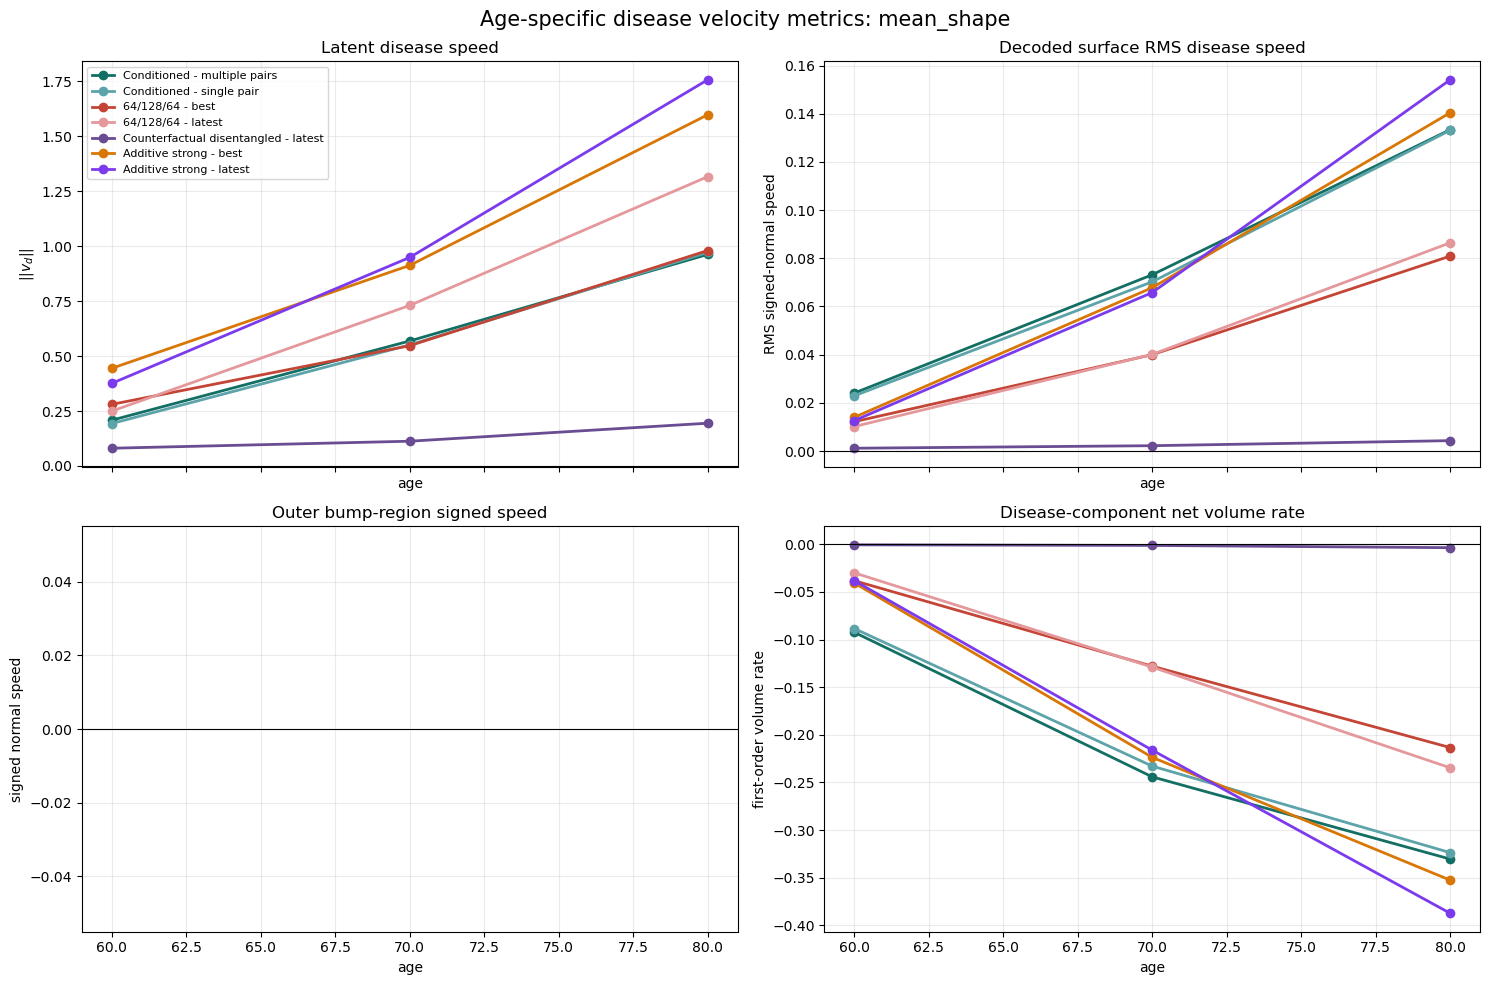

Saved figure: /home/jakaria/INR/Deep3DComp/analysis_torus_age_specific_disease_velocity/figures/metrics__ID_017_near_60.png


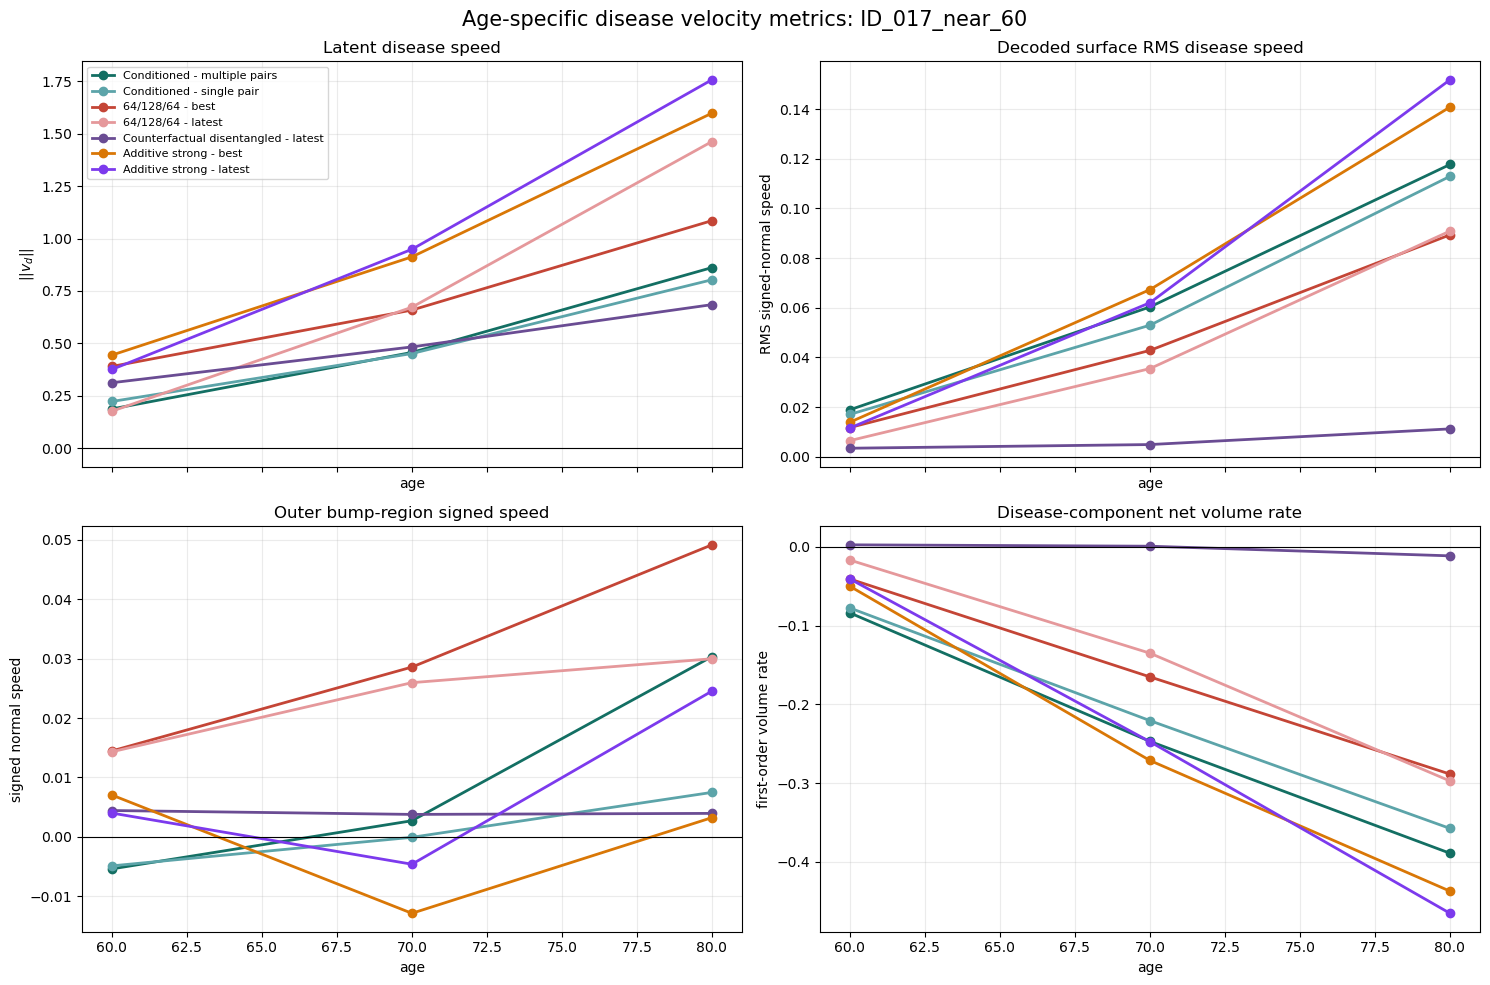

Saved figure: /home/jakaria/INR/Deep3DComp/analysis_torus_age_specific_disease_velocity/figures/metrics__ID_028_near_70.png


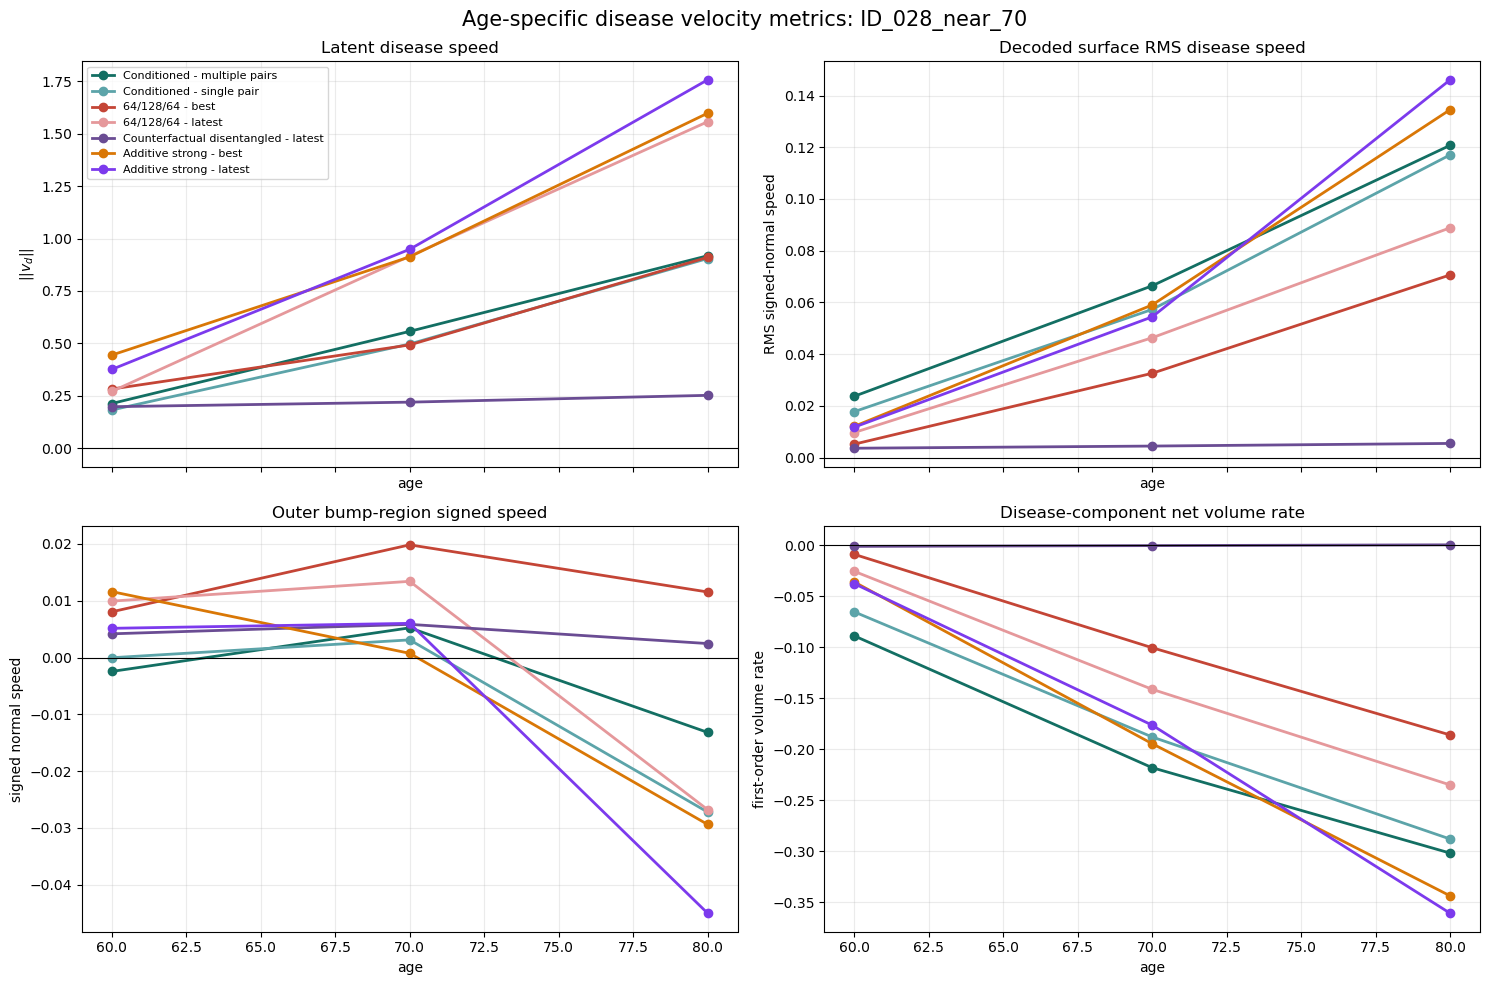

Saved figure: /home/jakaria/INR/Deep3DComp/analysis_torus_age_specific_disease_velocity/figures/metrics__ID_004_near_80.png


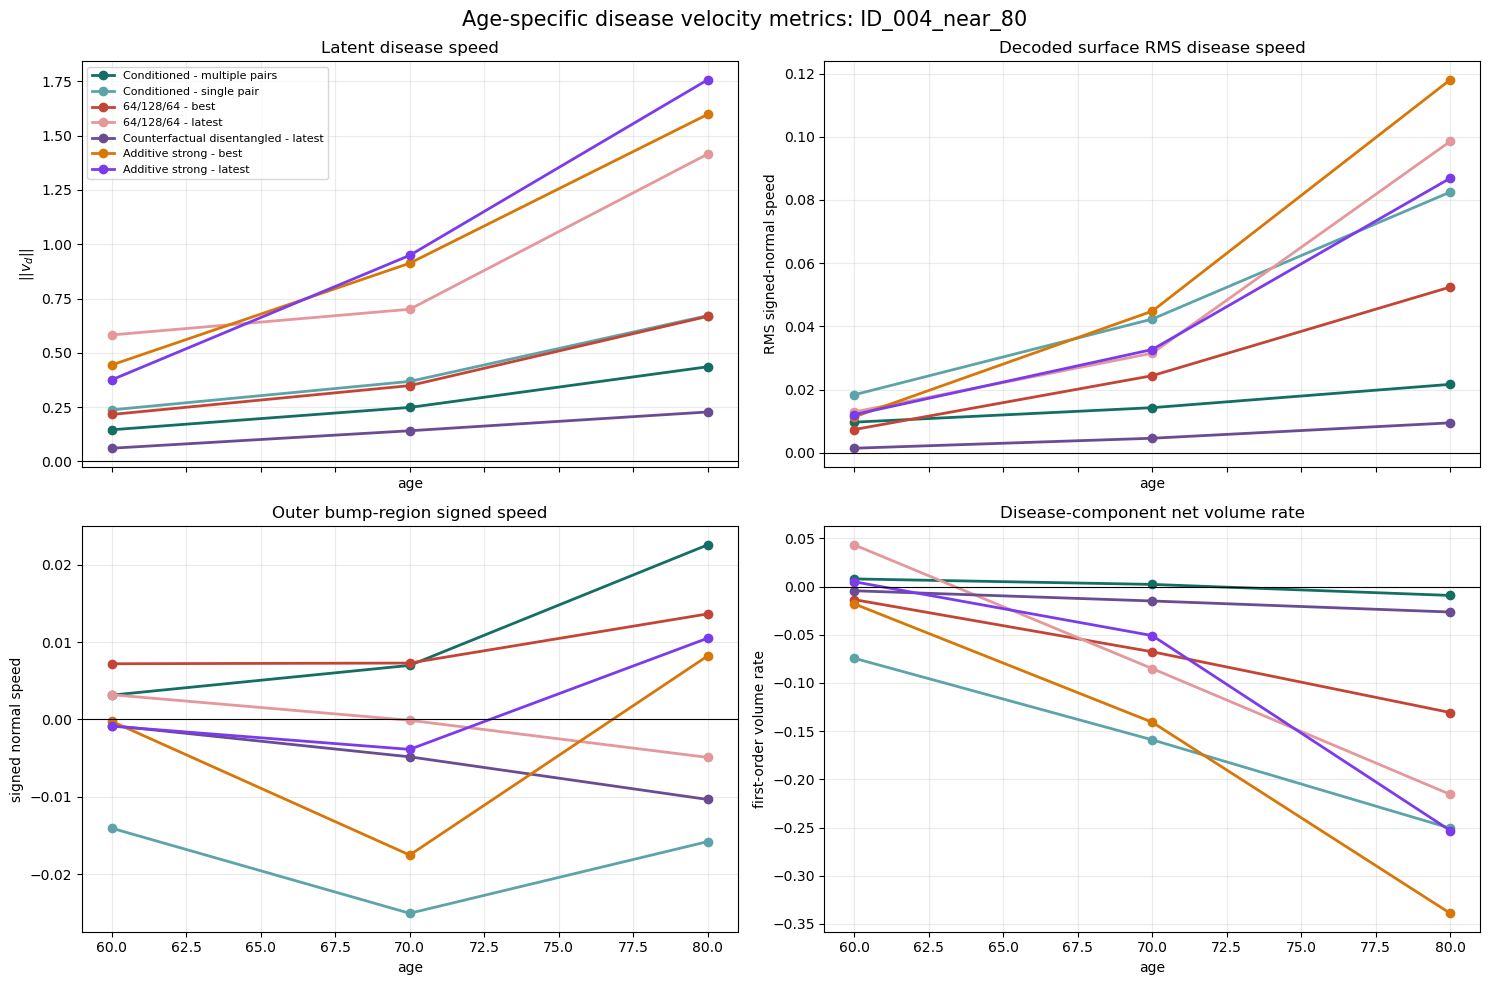

,anchor_key,model,epoch,age,inside_observed_range,disease_latent_speed,disease_surface_rms_speed,bump_signed_speed,bump_outward_fraction,disease_net_volume_rate,total_surface_rms_speed
69,ID_004_near_80,64/128/64 - best,500,60.0,False,0.216237,0.007325,0.007190,1.000000,-0.013566,0.035482
70,ID_004_near_80,64/128/64 - best,500,70.0,False,0.349099,0.024376,0.007281,0.829842,-0.067674,0.065361
71,ID_004_near_80,64/128/64 - best,500,80.0,True,0.667978,0.052438,0.013632,0.872230,-0.130719,0.126768
72,ID_004_near_80,64/128/64 - latest,2000,60.0,False,0.582433,0.012900,0.003189,0.863930,0.043264,0.021589
73,ID_004_near_80,64/128/64 - latest,2000,70.0,False,0.700655,0.031506,-0.000115,0.474204,-0.085102,0.085882
...,...,...,...,...,...,...,...,...,...,...,...
4,mean_shape,Conditioned - single pair,2000,70.0,NaN,0.550855,0.070239,NaN,NaN,-0.232806,0.127493
5,mean_shape,Conditioned - single pair,2000,80.0,NaN,0.972140,0.133113,NaN,NaN,-0.323624,0.227133
12,mean_shape,Counterfactual disentangled - latest,2000,60.0,NaN,0.080602,0.001171,NaN,NaN,-0.000522,0.037956
13,mean_shape,Counterfactual disentangled - latest,2000,70.0,NaN,0.112540,0.002224,NaN,NaN,-0.001168,0.090609


In [10]:
MODEL_COLORS = {
    "multiple_pairs": "#136F63",
    "single_pair": "#5CA4A9",
    "subset64_best": "#C44536",
    "subset64_latest": "#E5989B",
    "counterfactual_latest": "#6A4C93",
    "additive_best": "#D97706",
    "additive_latest": "#7C3AED",
}


def metric_figure(anchor_key):
    subset = METRICS[METRICS["anchor_key"] == anchor_key]
    fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
    columns = [
        ("disease_latent_speed", "Latent disease speed", r"$||v_d||$"),
        (
            "disease_surface_rms_speed",
            "Decoded surface RMS disease speed",
            "RMS signed-normal speed",
        ),
        (
            "bump_signed_speed",
            "Outer bump-region signed speed",
            "signed normal speed",
        ),
        (
            "disease_net_volume_rate",
            "Disease-component net volume rate",
            "first-order volume rate",
        ),
    ]
    for axis, (column, title, ylabel) in zip(axes.ravel(), columns):
        for model_name, model in MODELS.items():
            model_rows = subset[
                subset["model_key"] == model_name
            ].sort_values("age")
            axis.plot(
                model_rows["age"],
                model_rows[column],
                marker="o",
                linewidth=2,
                color=MODEL_COLORS[model_name],
                label=model["label"],
            )
        axis.axhline(0.0, color="black", linewidth=0.8)
        axis.set_title(title)
        axis.set_ylabel(ylabel)
        axis.set_xlabel("age")
        axis.grid(alpha=0.25)
    axes[0, 0].legend(fontsize=8)
    fig.suptitle(
        f"Age-specific disease velocity metrics: {anchor_key}", fontsize=15
    )
    fig.tight_layout()
    save_matplotlib_figure(
        fig,
        f"metrics__{anchor_key}",
        f"Velocity metrics: {anchor_key}",
        "Metric summaries",
    )


for anchor_key in ANCHORS:
    metric_figure(anchor_key)

display(
    METRICS[
        [
            "anchor_key",
            "model",
            "epoch",
            "age",
            "inside_observed_range",
            "disease_latent_speed",
            "disease_surface_rms_speed",
            "bump_signed_speed",
            "bump_outward_fraction",
            "disease_net_volume_rate",
            "total_surface_rms_speed",
        ]
    ].sort_values(["anchor_key", "model", "age"])
)


## Relative changes from age 60

This table answers questions such as: “Is disease velocity at age 75/80 larger than at
age 60?” A ratio greater than one means the measured speed increased relative to age 60.
Do not interpret a larger latent ratio as guaranteed larger surface deformation; use the
surface RMS ratio for that claim.


In [11]:
ratio_rows = []
for (anchor_key, model_name), group in METRICS.groupby(
    ["anchor_key", "model_key"]
):
    group = group.set_index("age")
    baseline = group.loc[60.0]
    for age in AGES:
        row = group.loc[age]
        ratio_rows.append(
            {
                "anchor_key": anchor_key,
                "model_key": model_name,
                "model": row["model"],
                "age": age,
                "latent_speed_ratio_vs_60": (
                    row["disease_latent_speed"]
                    / max(baseline["disease_latent_speed"], 1e-12)
                ),
                "surface_rms_ratio_vs_60": (
                    row["disease_surface_rms_speed"]
                    / max(baseline["disease_surface_rms_speed"], 1e-12)
                ),
                "bump_abs_speed_ratio_vs_60": (
                    abs(row["bump_signed_speed"])
                    / max(abs(baseline["bump_signed_speed"]), 1e-12)
                    if np.isfinite(row["bump_signed_speed"])
                    and np.isfinite(baseline["bump_signed_speed"])
                    else np.nan
                ),
            }
        )

SPEED_RATIOS = pd.DataFrame(ratio_rows)
display(SPEED_RATIOS)


,anchor_key,model_key,model,age,latent_speed_ratio_vs_60,surface_rms_ratio_vs_60,bump_abs_speed_ratio_vs_60
0,ID_004_near_80,additive_best,Additive strong - best,60.0,1.000000,1.000000,1.000000
1,ID_004_near_80,additive_best,Additive strong - best,70.0,2.054686,3.957210,69.420004
2,ID_004_near_80,additive_best,Additive strong - best,80.0,3.597827,10.428908,32.487905
3,ID_004_near_80,additive_latest,Additive strong - latest,60.0,1.000000,1.000000,1.000000
4,ID_004_near_80,additive_latest,Additive strong - latest,70.0,2.525575,2.707447,4.413266
...,...,...,...,...,...,...,...
79,mean_shape,subset64_best,64/128/64 - best,70.0,1.953582,3.286742,NaN
80,mean_shape,subset64_best,64/128/64 - best,80.0,3.499508,6.647331,NaN
81,mean_shape,subset64_latest,64/128/64 - latest,60.0,1.000000,1.000000,NaN
82,mean_shape,subset64_latest,64/128/64 - latest,70.0,2.929755,3.947641,NaN


## Optional local finite-step perturbation

The colored maps above show instantaneous velocity. This optional helper decodes
\(z_t+0.1v_d(t)\) and overlays the perturbed surface without arrows. It is useful for
checking whether the red/blue pattern creates a visibly consistent local shape change.
Call it for selected anchor/model pairs to avoid generating another large set of figures.


In [12]:
def perturbation_figure(anchor_key, model_name, local_step=LOCAL_STEP):
    fig = make_subplots(
        rows=1,
        cols=len(AGES),
        specs=[[{"type": "scene"}] * len(AGES)],
        column_titles=[f"Age {age:.0f}" for age in AGES],
    )
    for column, age in enumerate(AGES, start=1):
        result = RESULTS[anchor_key][model_name][age]
        base_mesh = result["geometry"]["mesh"]
        perturbed_latent = (
            result["latent"] + float(local_step) * result["disease_velocity"]
        )
        _, grid = decode_grid(
            MODELS[model_name]["decoder"], perturbed_latent, GRID_RES
        )
        perturbed_mesh = mesh_from_grid(grid)

        for mesh, color, opacity, name in [
            (base_mesh, "#D8D4CB", 0.82, "current surface"),
            (perturbed_mesh, "#00A6A6", 0.30, "z + step * disease velocity"),
        ]:
            vertices = np.asarray(mesh.vertices)
            faces = np.asarray(mesh.faces)
            fig.add_trace(
                go.Mesh3d(
                    x=vertices[:, 0],
                    y=vertices[:, 1],
                    z=vertices[:, 2],
                    i=faces[:, 0],
                    j=faces[:, 1],
                    k=faces[:, 2],
                    color=color,
                    opacity=opacity,
                    name=name,
                    showlegend=(column == 1),
                    hoverinfo="skip",
                ),
                row=1,
                col=column,
            )
    for scene_name in [
        key for key in fig.layout if str(key).startswith("scene")
    ]:
        fig.layout[scene_name].update(
            aspectmode="data",
            xaxis_visible=False,
            yaxis_visible=False,
            zaxis_visible=False,
            camera=dict(eye=dict(x=1.55, y=1.55, z=1.05)),
        )
    fig.update_layout(
        title=(
            f"Finite disease-component perturbation: {anchor_key} | "
            f"{MODELS[model_name]['label']} | step={local_step:g}"
        ),
        width=1200,
        height=520,
    )
    return fig


# Examples focused on the best and latest 64/128/64 checkpoints.
PERTURBATION_SELECTIONS = [
    ("mean_shape", "subset64_best"),
    ("mean_shape", "subset64_latest"),
    ("ID_004_near_80", "subset64_best"),
    ("ID_004_near_80", "subset64_latest"),
]
for anchor_key, model_name in PERTURBATION_SELECTIONS:
    figure = perturbation_figure(anchor_key, model_name)
    save_plotly_figure(
        figure,
        f"perturbation__{anchor_key}__{model_name}",
        f"Finite perturbation: {anchor_key} | {MODELS[model_name]['label']}",
        "Finite perturbation overlays",
        show_inline=(
            anchor_key in INLINE_PLOTLY_ANCHORS
            and model_name == "subset64_best"
        ),
    )


Saved figure: /home/jakaria/INR/Deep3DComp/analysis_torus_age_specific_disease_velocity/figures/perturbation__mean_shape__subset64_best.html
Saved figure: /home/jakaria/INR/Deep3DComp/analysis_torus_age_specific_disease_velocity/figures/perturbation__mean_shape__subset64_latest.html
Saved figure: /home/jakaria/INR/Deep3DComp/analysis_torus_age_specific_disease_velocity/figures/perturbation__ID_004_near_80__subset64_best.html
Saved figure: /home/jakaria/INR/Deep3DComp/analysis_torus_age_specific_disease_velocity/figures/perturbation__ID_004_near_80__subset64_latest.html


## Interpretation checklist

- Use the **mean-shape trajectory** to compare ages without subject-identity changes.
- Use `ID_017`, `ID_028`, and `ID_004` to check whether the pattern persists across
  subjects whose observed data support ages near 60, 70, and 80.
- A larger latent speed does not prove a larger visible deformation. Confirm with surface
  RMS speed and the colored maps.
- Red near the known bump region supports outward bump growth. Blue elsewhere supports
  global inward thinning.
- Stronger bump color at age 80 can coexist with a negative net volume rate because local
  bump expansion and global contraction occur simultaneously.
- Ages outside a subject's observed range are model extrapolations, not directly observed
  subject progression.
- The conditioned-model diagnosis contrast and disentangled disease component should be
  compared as disease-related effects, not treated as identical representations.


In [13]:
METRICS.to_csv(OUTPUT_DIR / "age_specific_velocity_metrics.csv", index=False)
SPEED_RATIOS.to_csv(OUTPUT_DIR / "age_specific_velocity_ratios.csv", index=False)
SELECTION_TABLE.to_csv(OUTPUT_DIR / "selected_subjects.csv", index=False)

summary = {
    "ages": list(AGES),
    "models": MODEL_TABLE.to_dict("records"),
    "selected_subjects": SELECTION_TABLE.to_dict("records"),
    "grid_resolution": int(GRID_RES),
    "local_step": float(LOCAL_STEP),
    "arrow_origin_offset": float(ARROW_ORIGIN_OFFSET),
    "velocity_definition": {
        "conditioned": "V(d=1) - V(d=0)",
        "disentangled": "explicit padded disease component",
    },
}
(OUTPUT_DIR / "summary.json").write_text(json.dumps(summary, indent=2))

index_path = write_figure_index()
relative_index = index_path.relative_to(ROOT)
display(
    HTML(
        f"<p><strong>All figures:</strong> "
        f"<a href='{relative_index.as_posix()}' target='_blank'>"
        f"{relative_index.as_posix()}</a></p>"
    )
)

print("Saved analysis:", OUTPUT_DIR)
print("Open this file for every visualization:", index_path)
for path in sorted(OUTPUT_DIR.iterdir()):
    print(" ", path.name)


Figure index: /home/jakaria/INR/Deep3DComp/analysis_torus_age_specific_disease_velocity/figures/index.html


Saved analysis: /home/jakaria/INR/Deep3DComp/analysis_torus_age_specific_disease_velocity
Open this file for every visualization: /home/jakaria/INR/Deep3DComp/analysis_torus_age_specific_disease_velocity/figures/index.html
  age_specific_velocity_metrics.csv
  age_specific_velocity_ratios.csv
  figures
  selected_subjects.csv
  summary.json
